1st column is the acceleration data in the X axis measured by the sensor ADXL345.
2nd column is the acceleration data in the Y axis measured by the sensor ADXL345.
3rd column is the acceleration data in the Z axis measured by the sensor ADXL345.

4th column is the rotation data in the X axis measured by the sensor ITG3200.
5th column is the rotation data in the Y axis measured by the sensor ITG3200.
6th column is the rotation data in the Z axis measured by the sensor ITG3200.

7th column is the acceleration data in the X axis measured by the sensor MMA8451Q.
8th column is the acceleration data in the Y axis measured by the sensor MMA8451Q.
9th column is the acceleration data in the Z axis measured by the sensor MMA8451Q.

File name format:
**<ADL OR FALL_CODE>_<SUBJECT_ID>_<TRIAL_NO>.txt**

**Activities of Daily Living (ADL):**

<!-- <div align="center"> -->

| Code | Activity                                                                                 | Trials | Duration |
|:----:|------------------------------------------------------------------------------------------|:------:|:--------:|
| D01  | Walking slowly                                                                           | 1      | 100s     |
| D02  | Walking quickly                                                                          | 1      | 100s     |
| D03  | Jogging slowly                                                                           | 1      | 100s     |
| D04  | Jogging quickly                                                                          | 1      | 100s     |
| D05  | Walking upstairs and downstairs slowly                                                   | 5      | 25s      |
| D06  | Walking upstairs and downstairs quickly                                                  | 5      | 25s      |
| D07  | Slowly sit in a half height chair, wait a moment, and up slowly                          | 5      | 12s      |
| D08  | Quickly sit in a half height chair, wait a moment, and up quickly                        | 5      | 12s      |
| D09  | Slowly sit in a low height chair, wait a moment, and up slowly                           | 5      | 12s      |
| D10  | Quickly sit in a low height chair, wait a moment, and up quickly                         | 5      | 12s      |
| D11  | Sitting a moment, trying to get up, and collapse into a chair                            | 5      | 12s      |
| D12  | Sitting a moment, lying slowly, wait a moment, and sit again                             | 5      | 12s      |
| D13  | Sitting a moment, lying quickly, wait a moment, and sit again                            | 5      | 12s      |
| D14  | Being on one's back change to lateral position, wait a moment, and change to one's back  | 5      | 12s      |
| D15  | Standing, slowly bending at knees, and getting up                                        | 5      | 12s      |
| D16  | Standing, slowly bending without bending knees, and getting up                           | 5      | 12s      |
| D17  | Standing, get into a car, remain seated and get out of the car                           | 5      | 25s      |
| D18  | Stumble while walking                                                                    | 5      | 12s      |
| D19  | Gently jump without falling (trying to reach a high object)                              | 5      | 12s      |


Falls:

| Code | Activity                                                                                 | Trials | Duration |
|:----:|------------------------------------------------------------------------------------------|:------:|:--------:|
| F01  | Fall forward while walking caused by a slip                                              | 5      | 15s      |
| F02  | Fall backward while walking caused by a slip                                             | 5      | 15s      |
| F03  | Lateral fall while walking caused by a slip                                              | 5      | 15s      |
| F04  | Fall forward while walking caused by a trip                                              | 5      | 15s      |
| F05  | Fall forward while jogging caused by a trip                                              | 5      | 15s      |
| F06  | Vertical fall while walking caused by fainting                                           | 5      | 15s      |
| F07  | Fall while walking, with use of hands in a table to dampen fall, caused by fainting      | 5      | 15s      |
| F08  | Fall forward when trying to get up                                                       | 5      | 15s      |
| F09  | Lateral fall when trying to get up                                                       | 5      | 15s      |
| F10  | Fall forward when trying to sit down                                                     | 5      | 15s      |
| F11  | Fall backward when trying to sit down                                                    | 5      | 15s      |
| F12  | Lateral fall when trying to sit down                                                     | 5      | 15s      |
| F13  | Fall forward while sitting, caused by fainting or falling asleep                         | 5      | 15s      |
| F14  | Fall backward while sitting, caused by fainting or falling asleep                        | 5      | 15s      |
| F15  | Lateral fall while sitting, caused by fainting or falling asleep                         | 5      | 15s      |
<!-- </div> -->

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# import os
# import zipfile
import functions as fn
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Path to zip file
# zip address for #! Amir :
# zip_file_path = 'DataSet/SisFall_dataset.zip'
# base_path = 'SisFall_dataset'

# zip address for #! Ali :
zip_file_path = '/Volumes/Windows SD/Master SSE/Semester 2/Fall Detection/DataSet.zip'
base_path = 'DataSet/SisFall_dataset'

# Create list of folder names (SA01 to SA23 and SE01 to SE15)
subject_ids = [f'SA{str(i).zfill(2)}' for i in range(1, 24)] + [f'SE{str(i).zfill(2)}' for i in range(1, 16)]

# all_data, all_labels, activity_code_list, adls, falls = fn.read_file(base_path, subject_ids)
all_data, all_labels, activity_code_list, file_name_list, adls, falls = fn.read_zip(zip_file_path, base_path, subject_ids)

print(f'number of total readings: {len(all_data)}')
print(f'number of total labels: {len(all_labels)}')
print(f'number of total activity codes: {len(activity_code_list)}')
print(f'number of total file names: {len(file_name_list)}')
print('------------------------------------------')
print(f'number of total ADL data: {len(adls)}')
print(f'number of total Fall data: {len(falls)}')
print('------------------------------------------')
# print number of unique labels and their counts
unique_labels, counts = np.unique(all_labels, return_counts=True)
print("Unique labels and their counts:")
for label, count in zip(unique_labels, counts):
    print(f"{label}: {count}")

# create a dictionary to map activity codes to real-world activities
activity_mapping = {
    "D01": "Walking slowly",
    "D02": "Walking quickly",
    "D03": "Jogging slowly",
    "D04": "Jogging quickly",
    "D05": "Walking upstairs and downstairs slowly",
    "D06": "Walking upstairs and downstairs quickly",
    "D07": "Slowly sit in a half height chair, wait a moment, and up slowly",
    "D08": "Quickly sit in a half height chair, wait a moment, and up quickly",
    "D09": "Slowly sit in a low height chair, wait a moment, and up slowly",
    "D10": "Quickly sit in a low height chair, wait a moment, and up quickly",
    "D11": "Sitting a moment, trying to get up, and collapse into a chair ",
    "D12": "Sitting a moment, lying slowly, wait a moment, and sit again",
    "D13": "Sitting a moment, lying quickly, wait a moment, and sit again",
    "D14": "Being on one's back change to lateral position, wait a moment, and change to one's back",
    "D15": "Standing, slowly bending at knees, and getting up",
    "D16": "Standing, slowly bending without bending knees, and getting up",
    "D17": "Standing, get into a car, remain seated and get out of the car",
    "D18": "Stumble while walking",
    "D19": "Gently jump without falling (trying to reach a high object)",
    "F" : "Fall",
    "F01": "Fall forward while walking caused by a slip",
    "F02": "Fall backward while walking caused by a slip",
    "F03": "Lateral fall while walking caused by a slip",
    "F04": "Fall forward while walking caused by a trip",
    "F05": "Fall backward while walking caused by a trip",
    "F06": "Vertical fall while walking caused by fainting",
    "F07": "Fall while walking, with use of hands in a table to dampen fall, caused by fainting",
    "F08": "Fall forward when trying to get up",
    "F09": "Lateral fall when trying to get up",
    "F10": "Fall forward when trying to sit down",
    "F11": "Fall backward when trying to sit down",
    "F12": "Lateral fall when trying to sit down",
    "F13": "Fall forward while sitting, caused by fainting or falling asleep",
    "F14": "Fall backward while sitting, caused by fainting or falling asleep",
    "F15": "Lateral fall while sitting, caused by fainting or falling asleep",
}



Progress: 4505/4505 files processed
Total files processed: 4505 ✅
Total ADL labels: 2707 ✅
Total Fall labels: 1798 ✅
number of total readings: 4505
number of total labels: 4505
number of total activity codes: 4505
number of total file names: 4505
------------------------------------------
number of total ADL data: 2707
number of total Fall data: 1798
------------------------------------------
Unique labels and their counts:
ADL: 2707
Fall: 1798


In [8]:
# rename all fall activity codes to 'F'
activity_code_list = ['F' if code.startswith('F') else code for code in activity_code_list]
activity_code_list

['D01',
 'D02',
 'D03',
 'D04',
 'D05',
 'D05',
 'D05',
 'D05',
 'D05',
 'D06',
 'D06',
 'D06',
 'D06',
 'D06',
 'D07',
 'D07',
 'D07',
 'D07',
 'D07',
 'D08',
 'D08',
 'D08',
 'D08',
 'D08',
 'D09',
 'D16',
 'D16',
 'D16',
 'D16',
 'D17',
 'D17',
 'D17',
 'D17',
 'D17',
 'D18',
 'D18',
 'D18',
 'D18',
 'D18',
 'D19',
 'D19',
 'D19',
 'D19',
 'D19',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'D09',
 'D16',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'F',
 'D09',
 'D09',
 'D09',
 'D10',
 'D10',
 'D10',
 'D10',
 'D10',
 'D11',
 'D11',
 'D11',
 'D11',
 'D11',
 'D12',
 'D12',
 'D12',
 'D12',
 'D12',
 'D13',
 'D13',
 'D13',
 'D13',
 'D13'

In [9]:

activity_data = {}

for code in activity_mapping.keys():
    indices = [i for i, act_code in enumerate(activity_code_list) if act_code == code]
    data_list = [all_data[i] for i in indices]
    file_names_list = [file_name_list[i] for i in indices]
    shapes_list = [d.shape for d in data_list]
    
    activity_data[code] = {
        "data": data_list,
        "file_names": file_names_list,
        "shapes": shapes_list
    }

In [12]:
for code, info in activity_data.items():
    print(f"{code}: {info['shapes']}")

D01: [(6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19997), (6, 19999), (6, 19999), (6, 19999), (6, 35999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19999), (6, 19985), (6, 19999), (6, 19999), (6, 19998), (6, 19999), (6, 19999), (6, 19999)]
D02: [(6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 19999), (6, 20000), (6, 20000), (6, 19999), (6, 19999), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 19999), (6, 20000), (6, 19999), (6, 20000), (6, 36000), (6, 20000), (6, 20001), (6, 20000), (6, 20001), (6, 20000), (6, 19999), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000)]
D03: [(6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000), (6, 20000)

In [51]:
processed_activities = {}

for code, info in activity_data.items():
    data_list = info["data"]
    file_names_list = info["file_names"]

    # Example processing: split_and_add for D01-D04, idle_remover+split_and_center for D05, etc.
    # You may want to adjust these per your actual processing logic.


    if code in ["D01", "D02", "D03", "D04"]:
        # Use split_and_add
        processed_data, processed_file_names, processed_activity_codes = fn.split_and_add(data_list, 800, file_names_list)
        processed_activities[code] = {
            "data": processed_data,
            "file_names": processed_file_names,
            "activity_codes": processed_activity_codes
        }
    elif code == "D05":
        # idle_remover + split_and_center
        cleaned_data = fn.idle_remover(data_list, 200, 30, mode='gyro')
        
        data_1, data_2 = fn.split_and_center(cleaned_data, 800)
        
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D06":
        cleaned_data = fn.idle_remover(data_list, 150, 30, mode='acc')
        data_1, data_2 = fn.split_and_center(cleaned_data, 800)
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D07":
        # extract_from_high_amp_segments
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.3, 700, 200, 800, "gyro")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "D08":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.14, 500, 100, 500, "gyro")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "D09":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.1, 700, 100, 700, "gyro")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "D10":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.1, 500, 100, 500, "gyro")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "D11":
        data = fn.keep_from_peak(data_list, 400)
        processed_activities[code] = {
            "data": data
        }
    elif code == "D12":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.2, 800, 200, 800, "gyro")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "D13":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.2, 500, 50, 500, "gyro")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "D14":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.15, 600, 100, 600, "gyro")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "D15":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 250, 250, 0.2, 700, 200, 800, "gyro")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "D16":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.15, 700, 200, 800, "gyro")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "D17":
        # Remove first 300 samples from each signal before processing
        trimmed_data = [d[:, 300:] for d in data_list]
        data_1, data_2 = fn.extract_from_high_amp_segments(trimmed_data, 300, 300, 0.3, 1000, 200, 1000, "gyro")
        processed_activities[code] = {
            "data_1": data_1,
            "data_2": data_2
        }
    elif code == "D18":
        data = fn.keep_from_peak(data_list, 400)
        processed_activities[code] = {
            "data": data
        }
    elif code == "D19":
        data_1, data_2 = fn.extract_from_high_amp_segments(data_list, 100, 100, 0.2, 400, 150, 500, "acc")
        new_1 = fn.length_fix(data_1, 800)
        new_2 = fn.length_fix(data_2, 800)
        processed_activities[code] = {
            "data_1": new_1,
            "data_2": new_2
        }
    elif code == "F":
        data = fn.keep_from_peak(data_list, 400)
        processed_activities[code] = {
            "data": data,
            "file_names": file_names_list
        }
    else:
        print(f"Activity code {code} not processed yet.")
    # else:
    #     # For F01-F15 and any other codes, you can add similar processing as needed
    #     processed_activities[code] = {
    #         "data": data_list,
    #         "file_names": file_names_list
    #     }


number of new D01 data: 932 with shape: (932, 6, 800), file_names :932, activities: 932 
number of new D02 data: 964 with shape: (964, 6, 800), file_names :964, activities: 964 
number of new D03 data: 965 with shape: (965, 6, 800), file_names :965, activities: 965 
number of new D04 data: 915 with shape: (915, 6, 800), file_names :915, activities: 915 
190 files processed, Min length: 2800, Max length: 5000
190 files processed, Min length: 800, Max length: 800
190 files processed, Min length: 800, Max length: 800
118 files processed, Min length: 1350, Max length: 2550
118 files processed, Min length: 800, Max length: 800
118 files processed, Min length: 800, Max length: 800
Number of features extracted (f4): 190
190 files processed using scale: 0.3 
Min1: 800, Max1: 800 
Min2: 500, Max2: 800
190 files processed, Min length: 800, Max length: 800
190 files processed, Min length: 800, Max length: 800
Number of features extracted (f4): 190
190 files processed using scale: 0.14 
Min1: 500,

In [52]:
processed_activities['D01']['file_names'][9]

'D01_SA01_R01.txt'

In [53]:
# Extract first 3 rows (accelerometer axes) from all data arrays in processed_activities
accelerometer_data = {}

for code, info in processed_activities.items():
    accelerometer_data[code] = {}
    
    # Handle different data structures based on the keys present
    if "data" in info and "data_1" not in info and "data_2" not in info:
        # Single data array (D01-D04, D11, D18, and default cases)
        data_arrays = info["data"]
        
        # Extract first 3 rows from each array in the list
        accel_arrays = []
        for array in data_arrays:
            if array.shape[0] >= 3:  # Ensure array has at least 3 rows
                accel_arrays.append(array[:3, :])  # Take first 3 rows (accelerometer axes)
            else:
                accel_arrays.append(array)  # Keep as is if less than 3 rows
        
        accelerometer_data[code]["data"] = accel_arrays
    
    elif "data_1" in info and "data_2" in info:
        # Split data structure (D05-D10, D12-D17, D19)
        
        # Process data_1
        data_1_arrays = info["data_1"]
        accel_data_1 = []
        for array in data_1_arrays:
            if array.shape[0] >= 3:
                accel_data_1.append(array[:3, :])
            else:
                accel_data_1.append(array)
        accelerometer_data[code]["data_1"] = accel_data_1
        
        # Process data_2
        data_2_arrays = info["data_2"]
        accel_data_2 = []
        for array in data_2_arrays:
            if array.shape[0] >= 3:
                accel_data_2.append(array[:3, :])
            else:
                accel_data_2.append(array)
        accelerometer_data[code]["data_2"] = accel_data_2

# Print summary of extracted data
print("Accelerometer data extraction summary:")
print(f"Total activity codes processed: {len(accelerometer_data)}")

for code, data in accelerometer_data.items():
    if "data" in data:
        print(f"{code}: {len(data['data'])} arrays, shapes: {[arr.shape for arr in data['data'][:3]]}")
    elif "data_1" in data and "data_2" in data:
        print(f"{code}: data_1 has {len(data['data_1'])} arrays, data_2 has {len(data['data_2'])} arrays")
        if data['data_1']:
            print(f"  data_1 sample shapes: {[arr.shape for arr in data['data_1'][:3]]}")
        if data['data_2']:
            print(f"  data_2 sample shapes: {[arr.shape for arr in data['data_2'][:3]]}")

Accelerometer data extraction summary:
Total activity codes processed: 20
D01: 932 arrays, shapes: [(3, 800), (3, 800), (3, 800)]
D02: 964 arrays, shapes: [(3, 800), (3, 800), (3, 800)]
D03: 965 arrays, shapes: [(3, 800), (3, 800), (3, 800)]
D04: 915 arrays, shapes: [(3, 800), (3, 800), (3, 800)]
D05: data_1 has 190 arrays, data_2 has 190 arrays
  data_1 sample shapes: [(3, 800), (3, 800), (3, 800)]
  data_2 sample shapes: [(3, 800), (3, 800), (3, 800)]
D06: data_1 has 118 arrays, data_2 has 118 arrays
  data_1 sample shapes: [(3, 800), (3, 800), (3, 800)]
  data_2 sample shapes: [(3, 800), (3, 800), (3, 800)]
D07: data_1 has 190 arrays, data_2 has 190 arrays
  data_1 sample shapes: [(3, 800), (3, 800), (3, 800)]
  data_2 sample shapes: [(3, 800), (3, 800), (3, 800)]
D08: data_1 has 190 arrays, data_2 has 190 arrays
  data_1 sample shapes: [(3, 800), (3, 800), (3, 800)]
  data_2 sample shapes: [(3, 800), (3, 800), (3, 800)]
D09: data_1 has 185 arrays, data_2 has 185 arrays
  data_1 sam

In [55]:

# Step 1: Map activity codes to labels
activity_mapper = {
    "D01": {"label": "Walking", "data": accelerometer_data["D01"]["data"]},
    "D02": {"label": "Walking", "data": accelerometer_data["D02"]["data"]},
    "D03": {"label": "Jogging", "data": accelerometer_data["D03"]["data"]},
    "D04": {"label": "Jogging", "data": accelerometer_data["D04"]["data"]},
    "D05": {"label": "Stairs",  "data": accelerometer_data["D05"]["data_1"]},
    "D06": {"label": "Stairs",  "data": accelerometer_data["D06"]["data_1"]},
    "D07": {"label": "Sitting", "data": accelerometer_data["D07"]["data_1"]},
    "D08": {"label": "Sitting", "data": accelerometer_data["D08"]["data_1"]},
    "D09": {"label": "Sitting", "data": accelerometer_data["D09"]["data_1"]},
    "D10": {"label": "Sitting", "data": accelerometer_data["D10"]["data_1"]},
    "F"  : {"label": "Fall",    "data": accelerometer_data["F"]["data"]},
}


In [64]:
# activity_mapper["D08"]["data"][10].shape
activity_mapper["F"]["label"]

'Fall'

In [78]:
len(activity_mapper["D02"]["data"])

964

In [65]:


# Step 2: Convert to DataFrame
all_dfs = []

for code, info in activity_mapper.items():
    label = info["label"]
    samples = info["data"]  # list of (6, time) arrays

    for i, sample in enumerate(samples):
        if sample.shape[0] != 3:
            continue  # Skip if not 6 channels

        time_series_length = sample.shape[1]
        time_axis = np.arange(time_series_length) / 200  # Assuming 200 Hz sampling rate

        df = pd.DataFrame({
            'ID': f'{code}_{i+1}',
            'Tag': label,
            'Time': time_axis,
            'Acc X': sample[0],
            'Acc Y': sample[1],
            'Acc Z': sample[2],

        })
        all_dfs.append(df)

# Step 3: Merge all into a single DataFrame
final_df = pd.concat(all_dfs, ignore_index=True)


In [66]:
def get_g(arr):
    # Convert raw accelerometer values to g
    range_ = 8
    res = 14  # specified by authors
    return ((2 * range_) / (2 ** res)) * np.array(arr)

def magnitude(x, y, z):
    x = x.astype('float')
    y = y.astype('float')
    z = z.astype('float')
    mag = np.sqrt(x ** 2 + y ** 2 + z ** 2)
    return mag

# Combine into single DataFrame
final_df = pd.concat(all_dfs, ignore_index=True)

# Convert accelerometer readings to g
final_df['Acc X'] = get_g(final_df['Acc X'])
final_df['Acc Y'] = get_g(final_df['Acc Y'])
final_df['Acc Z'] = get_g(final_df['Acc Z'])

# Compute acceleration magnitude and normalize
final_df['Acc Magnitude'] = magnitude(
    final_df['Acc X'], final_df['Acc Y'], final_df['Acc Z']
)
final_df['Acc Magnitude'] -= final_df['Acc Magnitude'].min()

In [67]:
final_df

,ID,Tag,Time,Acc X,Acc Y,Acc Z,Acc Magnitude
0,D01_1,Walking,0.000,0.016602,-0.174805,-0.096680,0.198264
1,D01_1,Walking,0.005,0.014648,-0.169922,-0.087891,0.189683
2,D01_1,Walking,0.010,0.000977,-0.171875,-0.079102,0.187023
3,D01_1,Walking,0.015,-0.009766,-0.175781,-0.075195,0.189255
4,D01_1,Walking,0.020,-0.020508,-0.186523,-0.061523,0.195292
...,...,...,...,...,...,...,...
5305595,F_1798,Fall,3.975,0.188477,0.078125,-0.144531,0.247849
5305596,F_1798,Fall,3.980,0.190430,0.076172,-0.146484,0.249855
5305597,F_1798,Fall,3.985,0.189453,0.078125,-0.148438,0.250857
5305598,F_1798,Fall,3.990,0.187500,0.081055,-0.147461,0.249751


In [68]:
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters

# 1. Melt the DataFrame into tsfresh-friendly format
melted_df = final_df.melt(
    id_vars=["ID", "Time"],
    value_vars=["Acc X", "Acc Y", "Acc Z"],
    var_name="Tag",  # Becomes 'kind' in tsfresh
    value_name="value"
)

# 2. Rename columns as required by tsfresh
melted_df = melted_df.rename(columns={
    "ID": "id",
    "Time": "time",
    "Tag": "kind"
})

# 3. Extract features using MinimalFCParameters
minimal_features = MinimalFCParameters()

extracted_features_minimal = extract_features(
    melted_df,
    column_id='id',
    column_sort='time',
    column_kind='kind',
    column_value='value',
    default_fc_parameters=minimal_features,
    n_jobs=1
)

Feature Extraction: 100%|██████████| 19896/19896 [00:25<00:00, 769.68it/s] 


In [69]:
extracted_features_minimal

,Acc X__sum_values,Acc X__median,Acc X__mean,Acc X__length,Acc X__standard_deviation,Acc X__variance,Acc X__root_mean_square,Acc X__maximum,Acc X__absolute_maximum,Acc X__minimum,...,Acc Z__sum_values,Acc Z__median,Acc Z__mean,Acc Z__length,Acc Z__standard_deviation,Acc Z__variance,Acc Z__root_mean_square,Acc Z__maximum,Acc Z__absolute_maximum,Acc Z__minimum
D01_1,8.889648,0.011719,0.011112,800.0,0.037439,0.001402,0.039053,0.120117,0.120117,-0.099609,...,-17.299805,-0.021484,-0.021625,800.0,0.041868,0.001753,0.047123,0.074219,0.151367,-0.151367
D01_10,8.889648,0.011719,0.011112,800.0,0.037439,0.001402,0.039053,0.120117,0.120117,-0.099609,...,-17.299805,-0.021484,-0.021625,800.0,0.041868,0.001753,0.047123,0.074219,0.151367,-0.151367
D01_100,5.396484,0.005859,0.006746,800.0,0.030393,0.000924,0.031133,0.126953,0.126953,-0.093750,...,0.499023,0.003906,0.000624,800.0,0.031208,0.000974,0.031214,0.095703,0.095703,-0.090820
D01_101,5.396484,0.005859,0.006746,800.0,0.030393,0.000924,0.031133,0.126953,0.126953,-0.093750,...,0.499023,0.003906,0.000624,800.0,0.031208,0.000974,0.031214,0.095703,0.095703,-0.090820
D01_102,5.396484,0.005859,0.006746,800.0,0.030393,0.000924,0.031133,0.126953,0.126953,-0.093750,...,0.499023,0.003906,0.000624,800.0,0.031208,0.000974,0.031214,0.095703,0.095703,-0.090820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F_995,63.684570,0.111328,0.079606,800.0,0.088105,0.007763,0.118742,0.782227,0.782227,-0.236328,...,-125.453125,-0.224609,-0.156816,800.0,0.149738,0.022422,0.216825,0.179688,1.235352,-1.235352
F_996,-56.210938,-0.046387,-0.070264,800.0,0.172074,0.029609,0.185867,0.354492,1.114258,-1.114258,...,40.677734,0.062012,0.050847,800.0,0.143568,0.020612,0.152306,0.283203,0.772461,-0.772461
F_997,-77.773438,-0.110352,-0.097217,800.0,0.151895,0.023072,0.180342,0.215820,0.915039,-0.915039,...,-101.475586,-0.116211,-0.126844,800.0,0.121723,0.014816,0.175801,0.227539,0.542969,-0.542969
F_998,-58.262695,-0.032227,-0.072828,800.0,0.172747,0.029842,0.187471,0.243164,1.571289,-1.571289,...,-100.801758,-0.098145,-0.126002,800.0,0.121769,0.014828,0.175227,0.280273,0.439453,-0.439453


In [73]:
len(data_list)

1798

=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

        Fall       1.00      0.99      0.99       719
     Jogging       0.99      1.00      0.99       752
     Sitting       0.98      0.97      0.98       300
      Stairs       0.94      0.91      0.93       123
     Walking       0.99      1.00      1.00       759

    accuracy                           0.99      2653
   macro avg       0.98      0.97      0.98      2653
weighted avg       0.99      0.99      0.99      2653

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

        Fall       1.00      0.99      1.00       719
     Jogging       0.99      1.00      0.99       752
     Sitting       1.00      1.00      1.00       300
      Stairs       0.99      0.94      0.97       123
     Walking       1.00      1.00      1.00       759

    accuracy                           1.00      2653
   macro avg       0.99      0.99      0.99

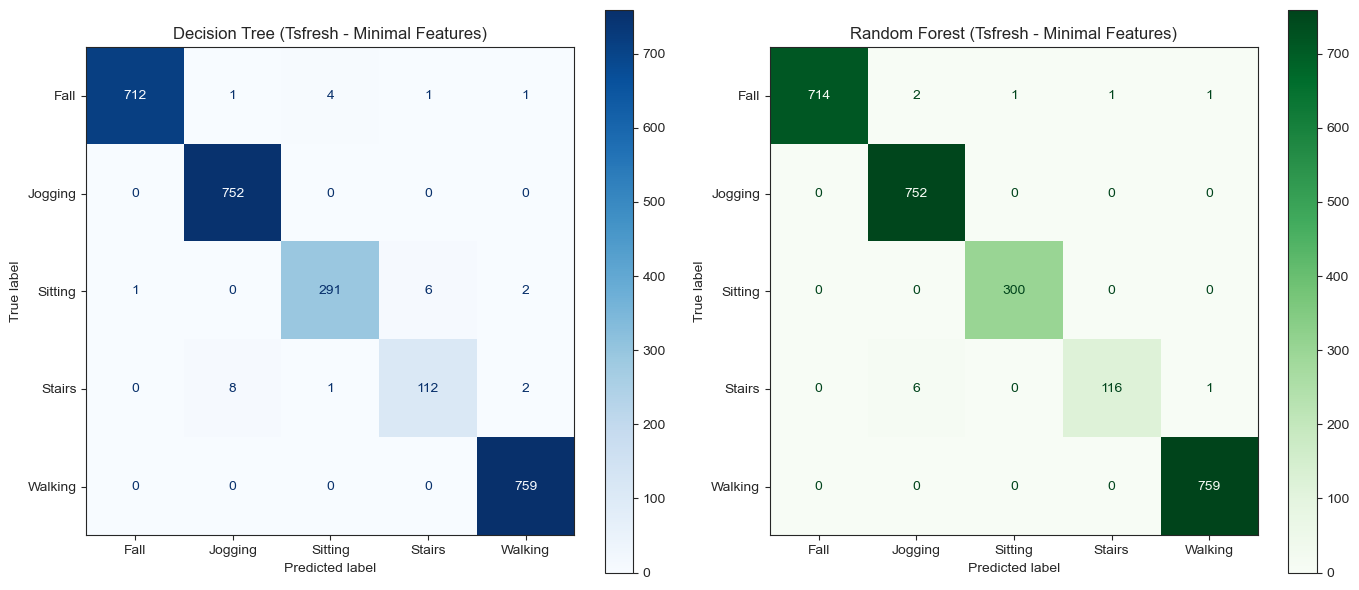

In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute

# -----------------------
# Build label Series from activity_mapper
# -----------------------

id_label_pairs = []
for key, info in activity_mapper.items():
    label = info["label"]
    data_list = info["data"]
    for i in range(len(data_list)):
        sample_id = f'{key}_{i+1}'
        id_label_pairs.append((sample_id, label))

label_df = pd.DataFrame(id_label_pairs, columns=['ID', 'Label'])

# Align labels with extracted features
impute(extracted_features_minimal)

# Merge labels and features based on ID
all_labels = label_df.set_index('ID').loc[extracted_features_minimal.index]['Label']

# Select relevant features using labels
features_filtered = select_features(extracted_features_minimal, all_labels)

# -----------------------
# Model Training and Evaluation
# -----------------------

X = features_filtered
y = all_labels

# Train/Test split
X_full_train, X_full_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Feature selection on training data
X_filtered_train = select_features(X_full_train, y_train)
X_filtered_test = X_full_test[X_filtered_train.columns]
X_filtered_train = X_full_train[X_filtered_train.columns]

# -----------------------
# Decision Tree Classifier
# -----------------------

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_filtered_train, y_train)
y_pred_dt = dt_model.predict(X_filtered_test)

print("=== Decision Tree Classification Report ===")
print(classification_report(y_test, y_pred_dt))

# -----------------------
# Random Forest Classifier
# -----------------------

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_filtered_train, y_train)
y_pred_rf = rf_model.predict(X_filtered_test)

print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf))

# -----------------------
# Plot Confusion Matrices
# -----------------------

labels = sorted(y.unique())
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=labels)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=labels)
disp_dt.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title("Decision Tree (Tsfresh - Minimal Features)")

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels)
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title("Random Forest (Tsfresh - Minimal Features)")

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

        Fall       1.00      0.99      0.99       360
     Jogging       0.99      1.00      1.00       376
     Sitting       0.87      1.00      0.93       150
      Stairs       1.00      0.52      0.68        62
     Walking       0.97      1.00      0.99       379

    accuracy                           0.97      1327
   macro avg       0.97      0.90      0.92      1327
weighted avg       0.98      0.97      0.97      1327



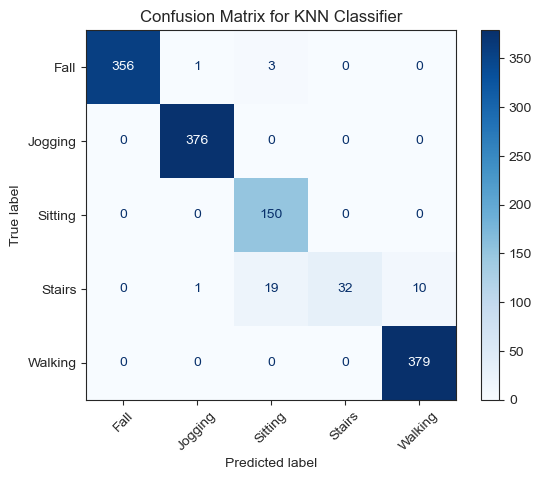

In [85]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = []  # Features: flattened signals
y = []  # Labels: activity names

for key, info in activity_mapper.items():
    label = info["label"]
    for sample in info["data"]:
        if sample.shape != (3, 800):  # only include correctly shaped data
            continue
        X.append(sample.flatten())  # from (3, 800) → (2400,)
        y.append(label)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix for KNN Classifier")
plt.show()

In [23]:
from scripts import classifiers
import sisfall_utils as sisfall
from scripts.uma import transform_uma_to_sisfall_format, uma_search_csv_files

files = uma_search_csv_files('output_uma')
uma_df = transform_uma_to_sisfall_format(files)


sisfall_df = sisfall.load()


# Load UMA file


# sisfall_cv_df, sisfall_aggr = classifiers.cross_validate(
#   sisfall, df=sisfall_df, model_type='tabular')



FileNotFoundError: [Errno 2] No such file or directory: 'DataSet/SisFall_MMA8451Q.pkl'

In [9]:
sisfall_df['Target'].unique()

array([0, 1], dtype=object)

In [10]:
uma_df['Target'].unique()

array([0])

=== TRAINING MODELS ===
Train subjects: 31, Test subjects: 7
Train set: X: (9947, 1400), y: (9947,) ([ADLs, Falls]: [8929 1018])
Test set: X: (2096, 1400), y: (2096,) ([ADLs, Falls]: [1914  182])
NaN values in training set: 10
NaN values in test set: 0
Imputing NaN values using strategy: knn

=== ExtraTreesClassifier ===
Train AUC: 1.000
Test AUC: 0.994
Overfitting gap: 0.006
✅ Good generalization

=== RandomForestClassifier ===
Train AUC: 1.000
Test AUC: 0.983
Overfitting gap: 0.017
✅ Good generalization

=== CONFUSION MATRICES ===


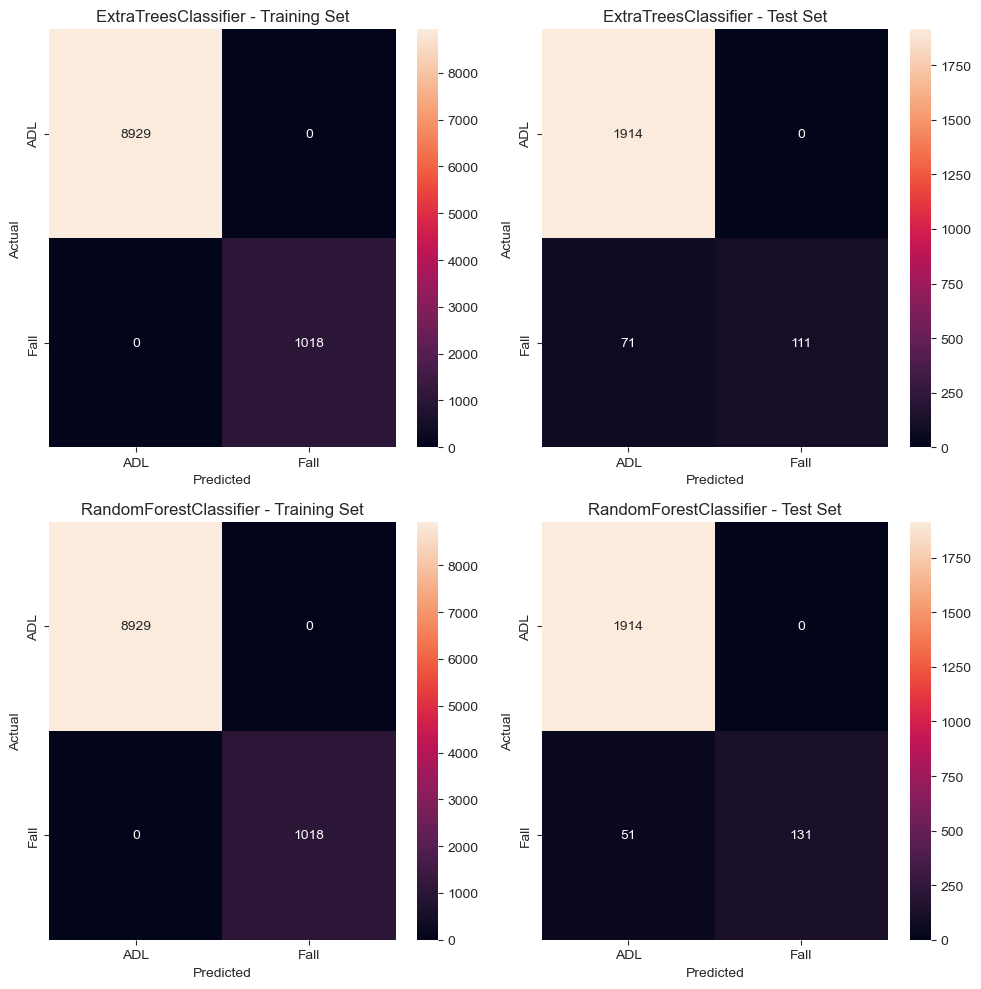


=== FEATURE IMPORTANCE ===


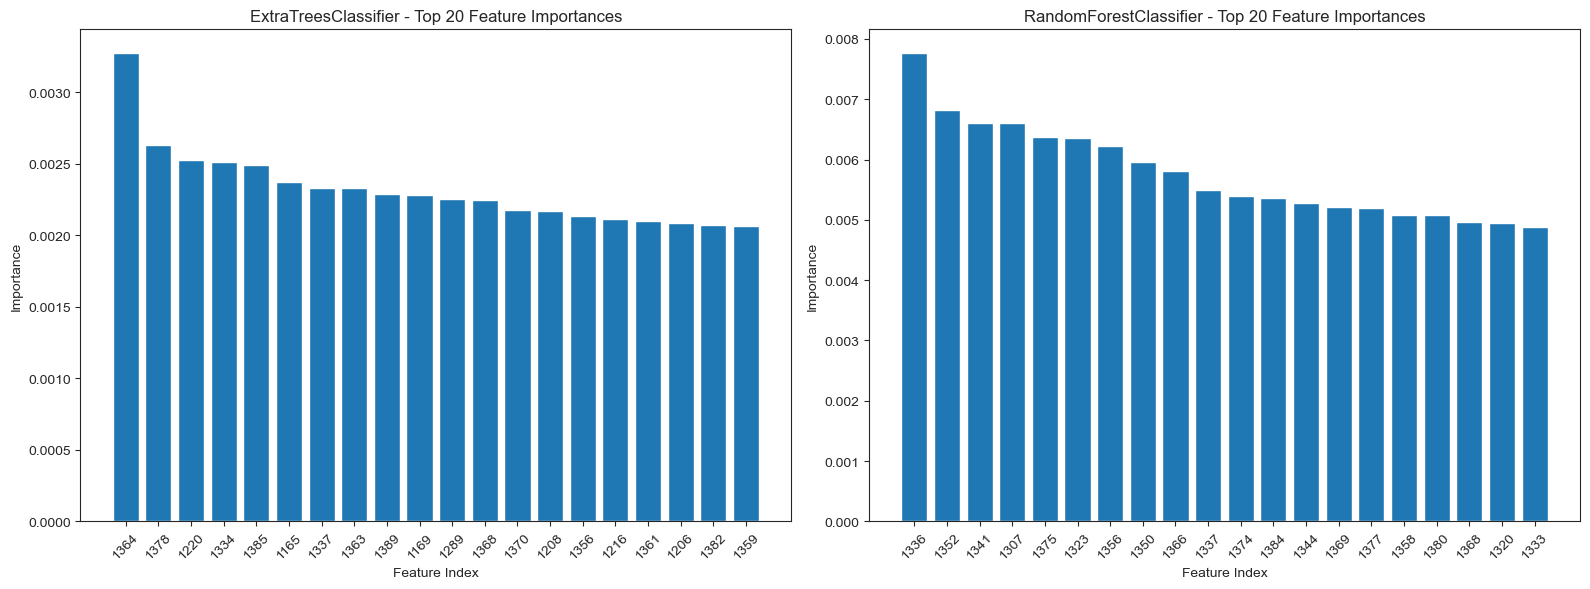


=== DETAILED CLASSIFICATION REPORTS ===

ExtraTreesClassifier - Test Set Classification Report:
              precision    recall  f1-score   support

         ADL       0.96      1.00      0.98      1914
        Fall       1.00      0.61      0.76       182

    accuracy                           0.97      2096
   macro avg       0.98      0.80      0.87      2096
weighted avg       0.97      0.97      0.96      2096


RandomForestClassifier - Test Set Classification Report:
              precision    recall  f1-score   support

         ADL       0.97      1.00      0.99      1914
        Fall       1.00      0.72      0.84       182

    accuracy                           0.98      2096
   macro avg       0.99      0.86      0.91      2096
weighted avg       0.98      0.98      0.97      2096



{'ExtraTreesClassifier': {'model': Pipeline(steps=[('imputer', KNNImputer()),
                  ('classifier', ExtraTreesClassifier(random_state=9))]),
  'train_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
  'test_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
  'train_auc': 1.0,
  'test_auc': 0.9942413907931149,
  'overfitting_gap': 0.00575860920688509},
 'RandomForestClassifier': {'model': Pipeline(steps=[('imputer', KNNImputer()),
                  ('classifier', RandomForestClassifier(random_state=9))]),
  'train_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
  'test_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=uint8),
  'train_auc': 1.0,
  'test_auc': 0.982676805952668,
  'overfitting_gap': 0.017323194047331958}}

In [11]:
from scripts.new_classifier_utils import full_model_analysis


results,(X_train, y_train, X_test, y_test) = full_model_analysis(sisfall, sisfall_df, handle_nans='impute', imputation_strategy='knn')
results

In [12]:
X_train

array([[0.60995378, 0.59021148, 0.55676324, ..., 0.43376884, 0.40981514,
        0.37881557],
       [0.63274906, 0.64226371, 0.66612619, ..., 0.33569905, 0.35989966,
        0.37059455],
       [0.43495152, 0.45936762, 0.49388774, ..., 0.41642008, 0.40723178,
        0.37526845],
       ...,
       [1.59746155, 1.64393661, 1.64529069, ..., 1.60778136, 1.63328479,
        1.66286987],
       [0.67581896, 0.87037667, 1.05385675, ..., 1.82777345, 1.88276304,
        1.93772   ],
       [1.80116884, 1.67944342, 1.54216923, ..., 0.12240169, 0.18147393,
        0.28463899]])

In [13]:
# One sample from sisfall
print("sisfall accel_g[0]:", type(sisfall_df.loc[0, 'accel_g']), np.array(sisfall_df.loc[0, 'accel_g']).shape)

# One sample from uma
print("uma_df accel_g[0]:", type(uma_df.loc[0, 'accel_g']), np.array(uma_df.loc[0, 'accel_g']).shape)


sisfall accel_g[0]: <class 'numpy.ndarray'> (20000,)
uma_df accel_g[0]: <class 'list'> (289, 3)


In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy import interpolate
from scipy.signal import resample
import pandas as pd

class CrossDatasetTester:
    """
    Class to handle testing models trained on one dataset on another dataset
    with potentially different feature dimensions
    """
    
    def __init__(self, trained_model, original_feature_size):
        self.trained_model = trained_model
        self.original_feature_size = original_feature_size
        self.scaler = None
        
    def preprocess_new_data(self, new_X, method='interpolate'):
        """
        Preprocess new data to match the feature size of the trained model
        
        Parameters:
        - new_X: numpy array of shape (n_samples, current_features)
        - method: 'interpolate', 'resample', 'pad_truncate', or 'extract_features'
        
        Returns:
        - processed_X: numpy array of shape (n_samples, original_feature_size)
        """
        
        if new_X.shape[1] == self.original_feature_size:
            print("✅ Feature sizes already match!")
            return new_X
            
        print(f"Adjusting features from {new_X.shape[1]} to {self.original_feature_size}")
        
        if method == 'interpolate':
            return self._interpolate_features(new_X)
        elif method == 'resample':
            return self._resample_features(new_X)
        elif method == 'pad_truncate':
            return self._pad_or_truncate_features(new_X)
        elif method == 'extract_features':
            return self._extract_statistical_features(new_X)
        else:
            raise ValueError("Method must be one of: 'interpolate', 'resample', 'pad_truncate', 'extract_features'")
    
    def _interpolate_features(self, X):
        """Use interpolation to resize features"""
        processed_X = np.zeros((X.shape[0], self.original_feature_size))
        
        for i, sample in enumerate(X):
            # Create interpolation function
            old_indices = np.linspace(0, 1, len(sample))
            new_indices = np.linspace(0, 1, self.original_feature_size)
            
            # Interpolate
            f = interpolate.interp1d(old_indices, sample, kind='linear')
            processed_X[i] = f(new_indices)
            
        return processed_X
    
    def _resample_features(self, X):
        """Use signal resampling to resize features"""
        processed_X = np.zeros((X.shape[0], self.original_feature_size))
        
        for i, sample in enumerate(X):
            processed_X[i] = resample(sample, self.original_feature_size)
            
        return processed_X
    
    def _pad_or_truncate_features(self, X):
        """Pad with zeros or truncate to match size"""
        processed_X = np.zeros((X.shape[0], self.original_feature_size))
        
        for i, sample in enumerate(X):
            if len(sample) >= self.original_feature_size:
                # Truncate
                processed_X[i] = sample[:self.original_feature_size]
            else:
                # Pad with zeros
                processed_X[i, :len(sample)] = sample
                
        return processed_X
    
    def _extract_statistical_features(self, X):
        """Extract statistical features to create fixed-size representation"""
        # This assumes each row in X is a time series
        # Extract common statistical features
        features_per_sample = []
        
        for sample in X:
            features = [
                np.mean(sample),
                np.std(sample),
                np.min(sample),
                np.max(sample),
                np.median(sample),
                np.percentile(sample, 25),
                np.percentile(sample, 75),
                len(sample),  # sequence length as feature
            ]
            features_per_sample.append(features)
        
        base_features = np.array(features_per_sample)
        
        # If we need more features, repeat or pad
        if base_features.shape[1] < self.original_feature_size:
            # Repeat features or pad with zeros
            repeat_factor = self.original_feature_size // base_features.shape[1]
            remainder = self.original_feature_size % base_features.shape[1]
            
            repeated = np.tile(base_features, (1, repeat_factor))
            if remainder > 0:
                repeated = np.concatenate([repeated, base_features[:, :remainder]], axis=1)
            return repeated
        else:
            # Truncate if too many features
            return base_features[:, :self.original_feature_size]
    
    def test_on_new_dataset(self, new_X, new_y, preprocessing_method='interpolate'):
        """
        Test the trained model on a new dataset
        
        Parameters:
        - new_X: Features from new dataset
        - new_y: Labels from new dataset
        - preprocessing_method: How to handle feature dimension mismatch
        
        Returns:
        - Dictionary with predictions and metrics
        """
        from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
        
        # Preprocess the new data
        processed_X = self.preprocess_new_data(new_X, method=preprocessing_method)
        
        # Make predictions
        predictions = self.trained_model.predict(processed_X)
        pred_proba = self.trained_model.predict_proba(processed_X)[:, 1]
        
        # Calculate metrics
        accuracy = accuracy_score(new_y, predictions)
        auc = roc_auc_score(new_y, pred_proba)
        
        results = {
            'predictions': predictions,
            'prediction_probabilities': pred_proba,
            'accuracy': accuracy,
            'auc': auc,
            'classification_report': classification_report(new_y, predictions),
            'confusion_matrix': confusion_matrix(new_y, predictions),
            'processed_features_shape': processed_X.shape
        }
        
        print(f"Cross-dataset testing results:")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"AUC: {auc:.3f}")
        print(f"Processed features shape: {processed_X.shape}")
        
        return results

def test_model_on_uma_dataset(sisfall_results, uma_X, uma_y, method='interpolate'):
    """
    Convenience function to test SisFall-trained model on UMA dataset
    
    Parameters:
    - sisfall_results: Results from train_and_analyze_models on SisFall
    - uma_X: UMA dataset features
    - uma_y: UMA dataset labels
    - method: Preprocessing method for dimension matching
    """
    
    # Get the best model from SisFall results (you can choose based on your criteria)
    best_model_name = max(sisfall_results.keys(), 
                         key=lambda k: sisfall_results[k]['test_auc'])
    best_model = sisfall_results[best_model_name]['model']
    
    print(f"Using best model: {best_model_name}")
    print(f"SisFall test AUC: {sisfall_results[best_model_name]['test_auc']:.3f}")
    
    # Get original feature size (assume from SisFall training)
    original_feature_size = uma_X.shape[1]  # You'll need to set this based on your SisFall features
    
    # Create tester and run cross-dataset evaluation
    tester = CrossDatasetTester(best_model, original_feature_size)
    results = tester.test_on_new_dataset(uma_X, uma_y, preprocessing_method=method)
    
    return results

# Alternative approach: Feature extraction pipeline
class UniversalFeatureExtractor:
    """
    Extract consistent features from accelerometer data regardless of sampling rate or window size
    """
    
    def __init__(self):
        self.feature_names = [
            'mean_x', 'mean_y', 'mean_z', 'mean_magnitude',
            'std_x', 'std_y', 'std_z', 'std_magnitude',
            'min_x', 'min_y', 'min_z', 'min_magnitude',
            'max_x', 'max_y', 'max_z', 'max_magnitude',
            'range_x', 'range_y', 'range_z', 'range_magnitude',
            'rms_x', 'rms_y', 'rms_z', 'rms_magnitude',
            'energy_x', 'energy_y', 'energy_z', 'total_energy',
            'correlation_xy', 'correlation_xz', 'correlation_yz'
        ]
    
    def extract_features(self, accel_data):
        """
        Extract features from accelerometer data
        
        Parameters:
        - accel_data: numpy array of shape (n_samples, 3) or (n_samples, n_timesteps, 3)
        
        Returns:
        - features: numpy array of extracted features
        """
        if accel_data.ndim == 3:
            # Multiple samples
            return np.array([self._extract_single_sample(sample) for sample in accel_data])
        else:
            # Single sample
            return self._extract_single_sample(accel_data)
    
    def _extract_single_sample(self, sample):
        """Extract features from a single accelerometer sample"""
        # Ensure sample is 2D (timesteps, 3_axes)
        if sample.ndim == 1:
            # If it's flattened, assume it's [x1,y1,z1,x2,y2,z2,...]
            sample = sample.reshape(-1, 3)
        
        x, y, z = sample[:, 0], sample[:, 1], sample[:, 2]
        magnitude = np.sqrt(x**2 + y**2 + z**2)
        
        features = []
        
        # Mean
        features.extend([np.mean(x), np.mean(y), np.mean(z), np.mean(magnitude)])
        
        # Standard deviation
        features.extend([np.std(x), np.std(y), np.std(z), np.std(magnitude)])
        
        # Min
        features.extend([np.min(x), np.min(y), np.min(z), np.min(magnitude)])
        
        # Max
        features.extend([np.max(x), np.max(y), np.max(z), np.max(magnitude)])
        
        # Range
        features.extend([np.ptp(x), np.ptp(y), np.ptp(z), np.ptp(magnitude)])
        
        # RMS
        features.extend([np.sqrt(np.mean(x**2)), np.sqrt(np.mean(y**2)), 
                        np.sqrt(np.mean(z**2)), np.sqrt(np.mean(magnitude**2))])
        
        # Energy
        features.extend([np.sum(x**2), np.sum(y**2), np.sum(z**2), 
                        np.sum(x**2) + np.sum(y**2) + np.sum(z**2)])
        
        # Correlations
        features.extend([np.corrcoef(x, y)[0,1], np.corrcoef(x, z)[0,1], 
                        np.corrcoef(y, z)[0,1]])
        
        return np.array(features)


uma_df.head()

,SubjectID,Activity,Duration (s),Acc,Target,accel_g
0,SA15,14,14.7,"[[0.9306640625, 0.061279296875, 0.35302734375]...",0,"[[0.9306640625, 0.061279296875, 0.35302734375]..."
1,SA15,14,14.7,"[[0.98681640625, 0.2119140625, 0.2099609375], ...",0,"[[0.98681640625, 0.2119140625, 0.2099609375], ..."
2,SA15,14,14.9,"[[0.926513671875, 0.143798828125, 0.4384765625...",0,"[[0.926513671875, 0.143798828125, 0.4384765625..."
3,SA15,14,14.8,"[[0.9326171875, 0.1474609375, 0.3662109375], [...",0,"[[0.9326171875, 0.1474609375, 0.3662109375], [..."
4,SA15,13,14.9,"[[1.001953125, 0.056396484375, 0.349853515625]...",0,"[[1.001953125, 0.056396484375, 0.349853515625]..."


In [15]:
def debug_dataset_structure(df, dataset_name="Dataset"):
    """
    Debug the structure of your dataset to understand the differences
    """
    print(f"\n=== {dataset_name} Debug Info ===")
    print(f"DataFrame shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    # Check target column
    if 'Target' in df.columns:
        print(f"Target unique values: {df['Target'].unique()}")
        print(f"Target value counts:\n{df['Target'].value_counts()}")
    else:
        print("❌ No 'Target' column found!")
        print("Available columns that might be target:", [col for col in df.columns if 'target' in col.lower() or 'label' in col.lower() or 'class' in col.lower()])
    
    # Check accelerometer data column
    accel_columns = [col for col in df.columns if 'accel' in col.lower()]
    print(f"Accelerometer columns: {accel_columns}")
    
    if accel_columns:
        accel_col = accel_columns[0]  # Use first accelerometer column
        print(f"\nAnalyzing '{accel_col}' column:")
        
        # Check first few samples
        for i in range(min(3, len(df))):
            sample = df.loc[i, accel_col]
            print(f"  Sample {i}: type={type(sample)}, ", end="")
            
            if isinstance(sample, (list, tuple)):
                print(f"length={len(sample)}, first_few={sample[:5] if len(sample) > 5 else sample}")
            elif isinstance(sample, np.ndarray):
                print(f"shape={sample.shape}, dtype={sample.dtype}")
            else:
                print(f"value={sample}")
    
    return accel_columns


debug_dataset_structure(sisfall_df, "SisFall")



=== SisFall Debug Info ===
DataFrame shape: (2445, 6)
Columns: ['SubjectID', 'Activity', 'Duration (s)', 'Acc', 'Target', 'accel_g']
Target unique values: [0 1]
Target value counts:
Target
1    1798
0     647
Name: count, dtype: int64
Accelerometer columns: ['accel_g']

Analyzing 'accel_g' column:
  Sample 0: type=<class 'numpy.ndarray'>, shape=(20000,), dtype=float64
  Sample 1: type=<class 'numpy.ndarray'>, shape=(20001,), dtype=float64
  Sample 2: type=<class 'numpy.ndarray'>, shape=(20001,), dtype=float64


['accel_g']

In [16]:
debug_dataset_structure(uma_df, "UMA")


=== UMA Debug Info ===
DataFrame shape: (678, 6)
Columns: ['SubjectID', 'Activity', 'Duration (s)', 'Acc', 'Target', 'accel_g']
Target unique values: [0]
Target value counts:
Target
0    678
Name: count, dtype: int64
Accelerometer columns: ['accel_g']

Analyzing 'accel_g' column:
  Sample 0: type=<class 'list'>, length=289, first_few=[[0.9306640625, 0.061279296875, 0.35302734375], [0.932373046875, 0.127197265625, 0.35595703125], [0.932373046875, 0.127197265625, 0.35595703125], [0.935791015625, 0.060791015625, 0.3603515625], [0.935791015625, 0.060791015625, 0.3603515625]]
  Sample 1: type=<class 'list'>, length=267, first_few=[[0.98681640625, 0.2119140625, 0.2099609375], [0.98681640625, 0.2119140625, 0.2099609375], [0.98681640625, 0.2119140625, 0.2099609375], [0.98681640625, 0.2119140625, 0.2099609375], [0.98681640625, 0.2119140625, 0.2099609375]]
  Sample 2: type=<class 'list'>, length=300, first_few=[[0.926513671875, 0.143798828125, 0.4384765625], [0.92578125, 0.143798828125, 0.43774

['accel_g']

In [17]:
import numpy as np
import pandas as pd
import re
from scipy.interpolate import interp1d
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def fix_uma_dataset(uma_df):
    """
    Fix UMA dataset to match SisFall format
    
    UMA format: accel_g = [[x,y,z], [x,y,z], ...] (list of 3D coordinates)
    SisFall format: accel_g = [x1,y1,z1,x2,y2,z2,...] (flattened numpy array)
    """
    print("🔧 Converting UMA dataset to SisFall format...")
    
    # Check if dataframe is empty
    if uma_df.empty:
        print("❌ UMA dataframe is empty!")
        return uma_df
    
    # Create a copy
    uma_fixed = uma_df.copy()
    
    # Reset index to ensure integer indexing works
    uma_fixed = uma_fixed.reset_index(drop=True)
    
    # Fix Target values based on Activity numbers
    print("🎯 Fixing Target values based on Activity numbers...")
    if 'Activity' in uma_fixed.columns:
        # Convert Activity to numeric, handling string values
        def extract_activity_number(activity_val):
            """Extract numeric value from Activity column"""
            try:
                if isinstance(activity_val, (int, float)):
                    return int(activity_val)
                elif isinstance(activity_val, str):
                    # Extract numbers from string (e.g., "Activity_13" -> 13)
                    import re
                    numbers = re.findall(r'\d+', str(activity_val))
                    if numbers:
                        return int(numbers[-1])  # Take the last number found
                    else:
                        return 0  # Default to 0 if no numbers found
                else:
                    return 0
            except (ValueError, TypeError):
                return 0
        
        # Apply the extraction function
        activity_numbers = uma_fixed['Activity'].apply(extract_activity_number)
        print(f"Activity numbers found: {sorted(activity_numbers.unique())}")
        
        # If Activity > 12, it's a fall (Target = 1), otherwise non-fall (Target = 0)
        uma_fixed['Target'] = (activity_numbers > 12).astype(int)
        print(f"Updated Target values: {uma_fixed['Target'].value_counts().to_dict()}")
    elif 'Target' not in uma_fixed.columns:
        print("⚠️  No Activity or Target column found - creating default Target=0")
        uma_fixed['Target'] = 0
    
    def clean_numeric_string(value_str):
        """
        Clean malformed numeric strings like '-1.442.138.671.875'
        Strategy: Remove extra periods, keeping only the last one as decimal point
        """
        if not isinstance(value_str, str):
            return value_str
        
        # Find all periods
        periods = [i for i, char in enumerate(value_str) if char == '.']
        
        if len(periods) <= 1:
            return value_str  # Normal case, 0 or 1 period
        
        # Multiple periods - keep only the last one as decimal point
        # Remove all periods except the last one
        result = ""
        for i, char in enumerate(value_str):
            if char == '.' and i != periods[-1]:
                continue  # Skip this period
            result += char
        
        return result
    
    def safe_float_convert(value):
        """
        Safely convert a value to float with cleaning
        """
        try:
            if isinstance(value, (int, float)):
                return float(value)
            elif isinstance(value, str):
                cleaned = clean_numeric_string(value)
                return float(cleaned)
            else:
                # Try direct conversion
                return float(value)
        except (ValueError, TypeError):
            # Return NaN for invalid values
            return np.nan
    
    def convert_uma_to_sisfall_format(uma_sample):
        """
        Convert UMA format [[x,y,z], [x,y,z], ...] to SisFall format [x,y,z,x,y,z,...]
        """
        if isinstance(uma_sample, list):
            try:
                flattened = []
                invalid_points = 0
                
                for point in uma_sample:
                    if isinstance(point, (list, tuple)) and len(point) == 3:
                        # Clean and convert each coordinate
                        x = safe_float_convert(point[0])
                        y = safe_float_convert(point[1])
                        z = safe_float_convert(point[2])
                        
                        # Check if any coordinate is invalid
                        if np.isnan(x) or np.isnan(y) or np.isnan(z):
                            invalid_points += 1
                            # Option 1: Skip invalid points (uncomment this)
                            # continue
                            
                            # Option 2: Replace with zeros (current approach)
                            x = 0.0 if np.isnan(x) else x
                            y = 0.0 if np.isnan(y) else y
                            z = 0.0 if np.isnan(z) else z
                        
                        flattened.extend([x, y, z])
                    else:
                        print(f"⚠️  Unexpected point format: {point}")
                        invalid_points += 1
                
                if invalid_points > 0:
                    print(f"⚠️  Found {invalid_points} invalid points in sample (replaced with zeros)")
                
                return np.array(flattened, dtype=np.float64)
                
            except Exception as e:
                print(f"❌ Error converting sample: {e}")
                return np.array([])
        else:
            print(f"❌ Unexpected sample type: {type(uma_sample)}")
            return np.array([])
    
    # Apply conversion
    print("Converting accelerometer data format...")
    uma_fixed['accel_g'] = uma_fixed['accel_g'].apply(convert_uma_to_sisfall_format)
    
    # Check conversion results - use safer indexing
    try:
        if len(uma_fixed) > 0:
            # Use .iloc for safer integer-based indexing
            first_sample = uma_fixed.iloc[0]
            sample_converted = first_sample['accel_g']
            original_sample = uma_df.iloc[0]['accel_g']
            
            print(f"✅ Conversion complete!")
            if isinstance(original_sample, list):
                print(f"Original UMA format: list of {len(original_sample)} 3D points")
                print(f"Expected: 3 * {len(original_sample)} = {3 * len(original_sample)} elements")
            print(f"Converted format: numpy array of shape {sample_converted.shape}")
            print(f"Actual: {len(sample_converted)} elements")
        else:
            print("⚠️  No samples to check conversion results")
    except Exception as e:
        print(f"⚠️  Could not check conversion results: {e}")
    
    # Report statistics about data quality
    total_samples = len(uma_fixed)
    if total_samples > 0:
        empty_samples = sum(1 for arr in uma_fixed['accel_g'] if len(arr) == 0)
        if empty_samples > 0:
            print(f"⚠️  Warning: {empty_samples}/{total_samples} samples are empty due to conversion errors")
    
    return uma_fixed

def fix_uma_dataset_aggressive(uma_df):
    """
    Alternative version with more aggressive data cleaning
    """
    print("🔧 Converting UMA dataset to SisFall format (aggressive cleaning)...")
    
    if uma_df.empty:
        print("❌ UMA dataframe is empty!")
        return uma_df
    
    uma_fixed = uma_df.copy()
    uma_fixed = uma_fixed.reset_index(drop=True)
    
    # Fix Target values
    print("🎯 Fixing Target values based on Activity numbers...")
    if 'Activity' in uma_fixed.columns:
        uma_fixed['Target'] = (uma_fixed['Activity'] > 12).astype(int)
        print(f"Updated Target values: {uma_fixed['Target'].value_counts().to_dict()}")
    elif 'Target' not in uma_fixed.columns:
        print("⚠️  No Activity or Target column found - creating default Target=0")
        uma_fixed['Target'] = 0
    
    def aggressive_clean_numeric(value_str):
        """
        More aggressive cleaning - remove all non-numeric characters except minus and one decimal point
        """
        if not isinstance(value_str, str):
            return value_str
        
        # Keep only digits, minus sign, and decimal points
        cleaned = re.sub(r'[^\d.-]', '', str(value_str))
        
        # Handle multiple decimal points - keep only the first one
        parts = cleaned.split('.')
        if len(parts) > 2:
            cleaned = parts[0] + '.' + ''.join(parts[1:])
        
        return cleaned
    
    def safe_float_convert_aggressive(value):
        """
        More aggressive float conversion
        """
        try:
            if isinstance(value, (int, float)):
                return float(value)
            elif isinstance(value, str):
                cleaned = aggressive_clean_numeric(value)
                if cleaned in ['', '-', '.']:
                    return 0.0
                return float(cleaned)
            else:
                return float(value)
        except (ValueError, TypeError):
            return 0.0  # Default to 0 instead of NaN
    
    def convert_uma_to_sisfall_format_aggressive(uma_sample):
        """
        Convert with aggressive cleaning
        """
        if isinstance(uma_sample, list):
            try:
                flattened = []
                
                for point in uma_sample:
                    if isinstance(point, (list, tuple)) and len(point) == 3:
                        # Aggressively clean and convert each coordinate
                        x = safe_float_convert_aggressive(point[0])
                        y = safe_float_convert_aggressive(point[1])
                        z = safe_float_convert_aggressive(point[2])
                        
                        flattened.extend([x, y, z])
                
                return np.array(flattened, dtype=np.float64)
                
            except Exception as e:
                print(f"❌ Error converting sample: {e}")
                # Return zeros instead of empty array
                expected_length = len(uma_sample) * 3 if hasattr(uma_sample, '__len__') else 0
                return np.zeros(expected_length, dtype=np.float64)
        else:
            print(f"❌ Unexpected sample type: {type(uma_sample)}")
            return np.array([])
    
    # Apply conversion
    print("Converting accelerometer data format with aggressive cleaning...")
    uma_fixed['accel_g'] = uma_fixed['accel_g'].apply(convert_uma_to_sisfall_format_aggressive)
    
    # Check conversion results
    try:
        if len(uma_fixed) > 0:
            sample_converted = uma_fixed.iloc[0]['accel_g']
            print(f"✅ Conversion complete!")
            print(f"Converted format: numpy array of shape {sample_converted.shape}")
    except Exception as e:
        print(f"⚠️  Could not check conversion results: {e}")
    
    return uma_fixed


def check_target_distribution(df, dataset_name):
    """
    Check and warn about target distribution issues
    """
    if df.empty:
        print(f"❌ {dataset_name} dataframe is empty!")
        return False
        
    if 'Target' not in df.columns:
        print(f"❌ {dataset_name} has no Target column!")
        return False
        
    target_counts = df['Target'].value_counts()
    print(f"\n📊 {dataset_name} Target Distribution:")
    print(target_counts)
    
    if len(target_counts) == 1:
        print(f"⚠️  WARNING: {dataset_name} contains only one class!")
        print("This might indicate:")
        print("- Missing fall data in your UMA dataset")
        print("- Incorrect target labeling")
        print("- Need to check your UMA data source")
        return False
    return True


def create_uma_X_y(uma_df_fixed):
    """
    Create X, y from the fixed UMA dataset
    """
    print("\n🔄 Creating X, y arrays from fixed UMA dataset...")
    
    if uma_df_fixed.empty:
        print("❌ Fixed UMA dataframe is empty!")
        return np.array([]), np.array([])
    
    X_list = []
    y_list = []
    
    for idx, row in uma_df_fixed.iterrows():
        accel_data = row['accel_g']
        target = row['Target']
        
        if isinstance(accel_data, np.ndarray) and len(accel_data) > 0:
            X_list.append(accel_data)
            y_list.append(target)
        else:
            print(f"⚠️  Skipping row {idx} due to invalid accelerometer data")
    
    if len(X_list) == 0:
        print("❌ No valid samples found!")
        return np.array([]), np.array([])
    
    # Convert to numpy arrays
    X = np.array(X_list, dtype=object)  # Object array due to variable lengths
    y = np.array(y_list)
    
    # Try to create regular numpy array if all samples have same length
    sample_lengths = [len(x) for x in X_list]
    if len(set(sample_lengths)) == 1:
        # All samples have same length - create regular array
        X = np.array(X_list)
        print(f"✅ Created regular numpy array: {X.shape}")
    else:
        print(f"⚠️  Variable sample lengths: {set(sample_lengths)}")
        print("Using object array - will need dimension matching for model testing")
    
    print(f"Final arrays - X: {X.shape if hasattr(X, 'shape') else f'{len(X)} samples'}, y: {y.shape}")
    return X, y


def handle_dimension_mismatch(sisfall_X_shape, uma_X, method='interpolate'):
    """
    Handle dimension mismatch between SisFall training data and UMA test data
    """
    if len(uma_X) == 0:
        print("❌ UMA X array is empty!")
        return uma_X
        
    target_size = sisfall_X_shape[1]  # Feature dimension from SisFall
    print(f"\n🔧 Handling dimension mismatch:")
    print(f"SisFall feature size: {target_size}")
    
    if isinstance(uma_X, np.ndarray) and uma_X.dtype == object:
        # Variable length samples
        uma_lengths = [len(sample) for sample in uma_X]
        print(f"UMA sample lengths: min={min(uma_lengths)}, max={max(uma_lengths)}, mean={np.mean(uma_lengths):.1f}")
        
        # Resize each sample
        uma_X_resized = np.zeros((len(uma_X), target_size))
        
        for i, sample in enumerate(uma_X):
            if method == 'interpolate' and len(sample) > 1:
                # Interpolation method
                old_indices = np.linspace(0, 1, len(sample))
                new_indices = np.linspace(0, 1, target_size)
                f = interp1d(old_indices, sample, kind='linear')
                uma_X_resized[i] = f(new_indices)
            else:
                # Pad/truncate method
                if len(sample) >= target_size:
                    uma_X_resized[i] = sample[:target_size]
                else:
                    uma_X_resized[i, :len(sample)] = sample
        
        print(f"✅ Resized UMA data to: {uma_X_resized.shape}")
        return uma_X_resized
    
    elif hasattr(uma_X, 'shape') and len(uma_X.shape) == 2:
        # Regular array but wrong size
        current_size = uma_X.shape[1]
        print(f"UMA current feature size: {current_size}")
        
        if current_size == target_size:
            print("✅ Dimensions already match!")
            return uma_X
        else:
            # Resize using interpolation
            uma_X_resized = np.zeros((uma_X.shape[0], target_size))
            for i, sample in enumerate(uma_X):
                if method == 'interpolate':
                    old_indices = np.linspace(0, 1, current_size)
                    new_indices = np.linspace(0, 1, target_size)
                    f = interp1d(old_indices, sample, kind='linear')
                    uma_X_resized[i] = f(new_indices)
                else:
                    # Pad/truncate
                    if current_size >= target_size:
                        uma_X_resized[i] = sample[:target_size]
                    else:
                        uma_X_resized[i, :current_size] = sample
            
            print(f"✅ Resized UMA data to: {uma_X_resized.shape}")
            return uma_X_resized
    
    else:
        print(f"❌ Unexpected UMA data format: {type(uma_X)}")
        return uma_X


def test_model_on_uma(sisfall_results, sisfall_X_train_shape, uma_X, uma_y):
    """
    Test SisFall-trained model on UMA dataset
    """
    print("\n🧪 Testing SisFall model on UMA dataset...")
    
    if len(uma_X) == 0 or len(uma_y) == 0:
        print("❌ UMA dataset is empty!")
        return None
    
    # Get best model from SisFall results
    if len(sisfall_results) > 0:
        best_model_name = max(sisfall_results.keys(), 
                             key=lambda k: sisfall_results[k]['test_auc'])
        best_model = sisfall_results[best_model_name]['model']
        
        print(f"Using best SisFall model: {best_model_name}")
        print(f"SisFall test AUC: {sisfall_results[best_model_name]['test_auc']:.3f}")
    else:
        print("❌ No SisFall results provided")
        return None
    
    # Handle dimension mismatch
    uma_X_processed = handle_dimension_mismatch(sisfall_X_train_shape, uma_X)
    
    if len(uma_X_processed) == 0:
        print("❌ Failed to process UMA data")
        return None
    
    # Check if we can make predictions
    if len(np.unique(uma_y)) == 1:
        print(f"⚠️  WARNING: UMA dataset contains only one class: {np.unique(uma_y)}")
        print("Cannot calculate AUC or meaningful classification metrics")
        
        # Still make predictions to see model behavior
        predictions = best_model.predict(uma_X_processed)
        pred_proba = best_model.predict_proba(uma_X_processed)[:, 1]
        
        print(f"Model predictions distribution: {np.bincount(predictions)}")
        print(f"Mean prediction probability: {np.mean(pred_proba):.3f}")
        print(f"Prediction probability range: [{np.min(pred_proba):.3f}, {np.max(pred_proba):.3f}]")
        
        return {
            'predictions': predictions,
            'prediction_probabilities': pred_proba,
            'uma_has_only_one_class': True,
            'processed_features_shape': uma_X_processed.shape
        }
    
    else:
        # Normal evaluation with both classes
        predictions = best_model.predict(uma_X_processed)
        pred_proba = best_model.predict_proba(uma_X_processed)[:, 1]
        
        accuracy = accuracy_score(uma_y, predictions)
        auc = roc_auc_score(uma_y, pred_proba)
        
        print(f"✅ Cross-dataset Results:")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"AUC: {auc:.3f}")
        print("\nClassification Report:")
        print(classification_report(uma_y, predictions))
        
        return {
            'predictions': predictions,
            'prediction_probabilities': pred_proba,
            'accuracy': accuracy,
            'auc': auc,
            'classification_report': classification_report(uma_y, predictions),
            'confusion_matrix': confusion_matrix(uma_y, predictions),
            'processed_features_shape': uma_X_processed.shape
        }


def complete_uma_testing_pipeline(sisfall_results, sisfall_X_train, uma_df):
    """
    Complete pipeline to test SisFall model on UMA dataset
    """
    print("🚀 Starting complete UMA testing pipeline...")
    
    # Step 1: Fix UMA dataset structure
    uma_df_fixed = fix_uma_dataset(uma_df)
    
    # Step 2: Check target distribution
    target_ok = check_target_distribution(uma_df_fixed, "UMA")
    
    # Step 3: Create X, y arrays
    uma_X, uma_y = create_uma_X_y(uma_df_fixed)
    
    # Step 4: Test model (only if we have valid data)
    if len(uma_X) > 0 and len(uma_y) > 0:
        results = test_model_on_uma(sisfall_results, sisfall_X_train.shape, uma_X, uma_y)
    else:
        print("❌ Cannot test model - no valid UMA data")
        results = None
    
    return results, uma_X, uma_y

In [18]:
# import re

# def fix_uma_targets(df):
#     """
#     Fix UMA target values based on Activity numbers.
#     Activities 13, 14, 15 should be labeled as falls (Target = 1)
#     All other activities should be labeled as non-falls (Target = 0)
#     """
#     df_fixed = df.copy()
    
#     def extract_activity_number(activity_val):
#         """Extract numeric value from Activity column"""
#         try:
#             if isinstance(activity_val, (int, float)):
#                 return int(activity_val)
#             elif isinstance(activity_val, str):
#                 # Extract numbers from string (e.g., "Activity13" -> 13)
#                 numbers = re.findall(r'\d+', str(activity_val))
#                 if numbers:
#                     return int(numbers[-1])  # Take the last number found
#                 else:
#                     return 0  # Default to 0 if no numbers found
#             else:
#                 return 0
#         except (ValueError, TypeError):
#             return 0
    
#     # Extract activity numbers
#     activity_numbers = df_fixed['Activity'].apply(extract_activity_number)
    
#     # Set Target: 1 for Activities 13, 14, 15 (falls), 0 for all others (non-falls)
#     df_fixed['Target'] = activity_numbers.isin([13, 14, 15]).astype(int)
    
#     print("Activity to Target mapping:")
#     activity_target_mapping = df_fixed.groupby('Activity')['Target'].first().sort_index()
#     for activity, target in activity_target_mapping.items():
#         activity_num = extract_activity_number(activity)
#         print(f"{activity} (Activity {activity_num}) -> Target {target}")
    
#     print(f"\nTarget distribution: {df_fixed['Target'].value_counts().to_dict()}")
    
#     return df_fixed

# # Apply the fix to uma_df
# uma_df = fix_uma_targets(uma_df)

In [ ]:
uma_df['Target']

,SubjectID,Activity,Duration (s),Acc,Target,accel_g
0,SA15,14,14.7,"[[0.9306640625, 0.061279296875, 0.35302734375]...",0,"[[0.9306640625, 0.061279296875, 0.35302734375]..."
1,SA15,14,14.7,"[[0.98681640625, 0.2119140625, 0.2099609375], ...",0,"[[0.98681640625, 0.2119140625, 0.2099609375], ..."
2,SA15,14,14.9,"[[0.926513671875, 0.143798828125, 0.4384765625...",0,"[[0.926513671875, 0.143798828125, 0.4384765625..."
3,SA15,14,14.8,"[[0.9326171875, 0.1474609375, 0.3662109375], [...",0,"[[0.9326171875, 0.1474609375, 0.3662109375], [..."
4,SA15,13,14.9,"[[1.001953125, 0.056396484375, 0.349853515625]...",0,"[[1.001953125, 0.056396484375, 0.349853515625]..."
...,...,...,...,...,...,...
673,SA09,7,14.8,"[[-0.92529296875, -0.087158203125, 0.229003906...",0,"[[-0.92529296875, -0.087158203125, 0.229003906..."
674,SA09,7,14.9,"[[-0.916015625, -0.17626953125, 0.280029296875...",0,"[[-0.916015625, -0.17626953125, 0.280029296875..."
675,SA09,9,14.8,"[[-0.86572265625, 0.340576171875, 0.1716308593...",0,"[[-0.86572265625, 0.340576171875, 0.1716308593..."
676,SA09,9,14.8,"[[-0.873291015625, 0.28955078125, 0.2053222656...",0,"[[-0.873291015625, 0.28955078125, 0.2053222656..."


In [20]:
results, uma_X, uma_y = complete_uma_testing_pipeline(
    sisfall_results=results,  # From your train_and_analyze_models
    sisfall_X_train=X_train,  # From your SisFall training
    uma_df=uma_df            # Your UMA dataset
)

🚀 Starting complete UMA testing pipeline...
🔧 Converting UMA dataset to SisFall format...
🎯 Fixing Target values based on Activity numbers...
Activity numbers found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Updated Target values: {0: 480, 1: 198}
Converting accelerometer data format...
✅ Conversion complete!
Original UMA format: list of 289 3D points
Expected: 3 * 289 = 867 elements
Converted format: numpy array of shape (867,)
Actual: 867 elements

📊 UMA Target Distribution:
Target
0    480
1    198
Name: count, dtype: int64

🔄 Creating X, y arrays from fixed UMA dataset...
⚠️  Variable sample lengths: {768, 897, 900, 516, 903, 777, 909, 912, 786, 789, 792, 801, 807, 810, 813, 816, 822, 825, 699, 828, 576, 834, 837, 840, 843, 846, 849, 852, 855, 345, 858, 861, 864, 738, 867, 870, 873, 618, 876, 879, 882, 756, 885, 888, 891, 894, 639}
Using object array - will need dimension matching for model testing
Final arrays - X: (678,), y: (678,)

🧪 Testing SisFall model on UMA datase

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-pa